# **Relatório Analítico de Evasão dos Alunos das Academias**

Este relatório foi feito baseado em um dataset de evasão dos alunos das academias disponibilizado públicamente no [Kaggle](https://www.kaggle.com/datasets/adrianvinueza/gym-customers-features-and-churn).




---



## **1) EDA (Análise Exploratória de Dados)**

### 1.1) Instalação de Pacotes e Importação de Bibliotecas e Frameworks


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

### 1.2) Extração do dataset

In [ ]:
import pandas as pd
data = pd.read_csv('/content/gym_churn_us.csv')

### 1.3) Auditoria dos Dados

In [ ]:
pd.set_option('display.max_columns', None)
display(data)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0


Aqui, verificamos que o dataset atual possui uma amostra de 4.000 linhas e 14 colunas distintas.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

A partir dessa informação, descobrimos que o dataset não possui valores nulos, um ótimo indicador de um dataset já processado e tratado, agora analisaremos os outliers.

In [ ]:
data.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


Como vimos acima, temos apenas uma pequena quantidade de outliers, sendo assim, podemos garantir que não irá gerar interferência ao resultado da análise.

Baseado nas informações obtidas e por estudos externos sobre cada atributo do dataset, montamos um dicionário de dados sobre.


### **Dicionário de Dados:**

- `gender:` Gênero do cliente (0 = Homem, 1 = Mulher).

- `Near_Location:` Indica se o cliente mora ou trabalha no mesmo bairro onde a academia está localizada (0 = Não, 1 = Sim).

- `Partner:` Indica se o cliente é funcionário de uma empresa parceira da academia (empresas conveniadas que oferecem descontos aos funcionários) (0 = Não, 1 = Sim).

- `Promo_friends:` Indica se o cliente se inscreveu originalmente através de uma oferta "indique um amigo" (usando um código promocional de um conhecido) (0 = Não, 1 = Sim).

- `Phone:` Indica se o cliente forneceu o número de telefone no cadastro (0 = Não, 1 = Sim).

- `Contract_period:` Duração do contrato atual em meses (ex: 1, 6 ou 12 meses).

- `Group_visits:` Indica se o cliente participa de aulas ou sessões em grupo (0 = Não, 1 = Sim).

- `Age:` Idade do cliente em anos.

- `Avg_additional_charges_total:` Média de gastos totais em serviços adicionais da academia (cafeteria, massagem, loja de produtos, etc.).

- `Month_to_end_contract:` Quantidade de meses restantes até o término do contrato atual.

- `Lifetime:` Tempo de permanência (em meses) desde a primeira visita à academia.

- `Avg_class_frequency_total:` Frequência média de visitas por semana desde que o cliente se matriculou.

- `Avg_class_frequency_current_month:` Frequência média de visitas por semana durante o último mês.

- `Churn:` Variável alvo que indica se o cliente cancelou a matrícula no mês atual (0 = Permaneceu, 1 = Cancelou/Saiu).

## **2) Visualização de dados**

In [ ]:
num_cols = [
'Contract_period',
'Age',
'Avg_additional_charges_total',
'Month_to_end_contract',
'Lifetime',
'Avg_class_frequency_total',
'Avg_class_frequency_current_month'
]

cat_cols = [
'gender',
'Near_Location',
'Partner',
'Promo_friends',
'Phone',
'Group_visits'
]


target_col = ['Churn']

dfs = []

palette = {0: '#00FF00', 1: '#FF0000'}

Aqui, dividimos as colunas entre do tipo `categórico` e `numérico`, além de definir alguns parâmetros a serem reutilizados no código.

### 2.1) Matriz de Correlação

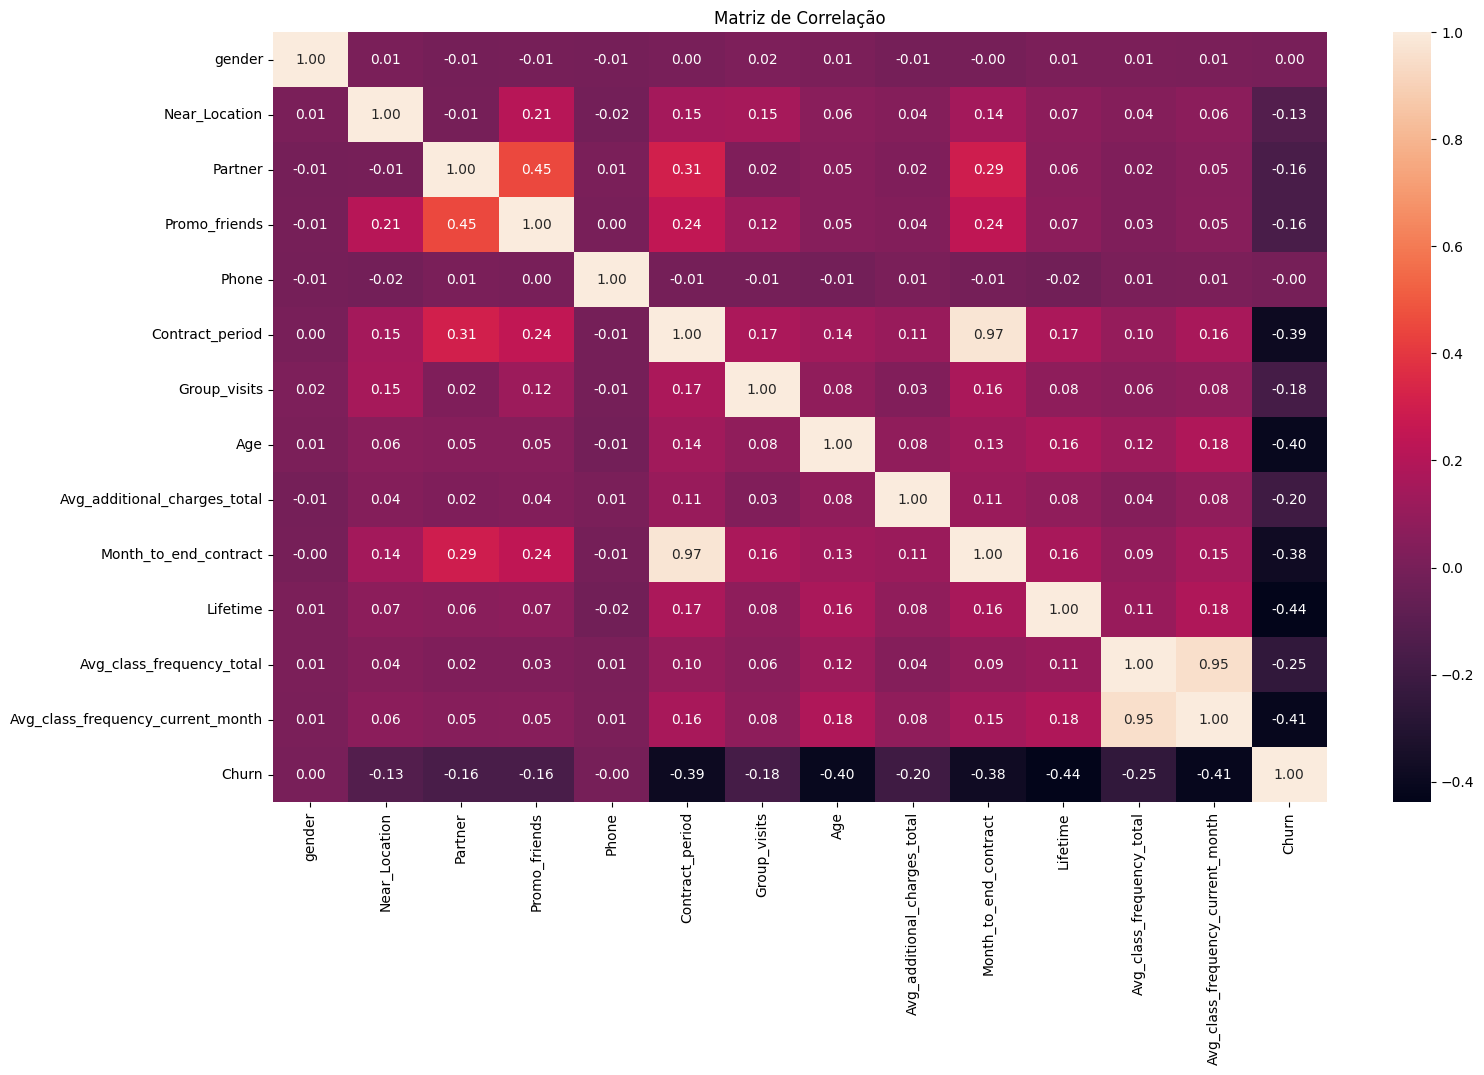

In [ ]:
plt.figure(figsize=(17, 10))
sns.heatmap(data.corr(), annot=True, fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

A Matriz de Correlação gerada aponta caminhos lineares diretos para o risco de cancelamento. Quatro variáveis destacam-se com fortíssimas correlações negativas com o Churn:

    Lifetime (-0.44): O tempo de permanência é o maior aliado contra o cancelamento.

    Avg_class_frequency_current_month (-0.41): A frequência de treinos no último mês é o termômetro em tempo real da desistência.

    Age (-0.40) e Contract_period (-0.39): Idades mais jovens e contratos curtos são sinônimos de instabilidade.

Todas as variáveis destacadas como negativas apresentam índices de correlação negativos médios, o que sugere que uma unica não seja suficiente para explicar a evasão, mas sim o conjunto delas, sugerindo que possívelmente exista um perfil de alunos que não permanecem naquela academia. Mapear esse perfil é de grande valor para o negócio.
<br>
<br>
Obs: Variáveis cadastrais como gênero (gender) ou o fato de registrar o telefone (Phone) têm correlação praticamente nula com o cancelamento. Focar em campanhas de marketing baseadas em gênero é perda de tempo e dinheiro; o foco da gestão tem que ser exclusivamente comportamental.

### 2.2) Histograma do Tempo de Contrato

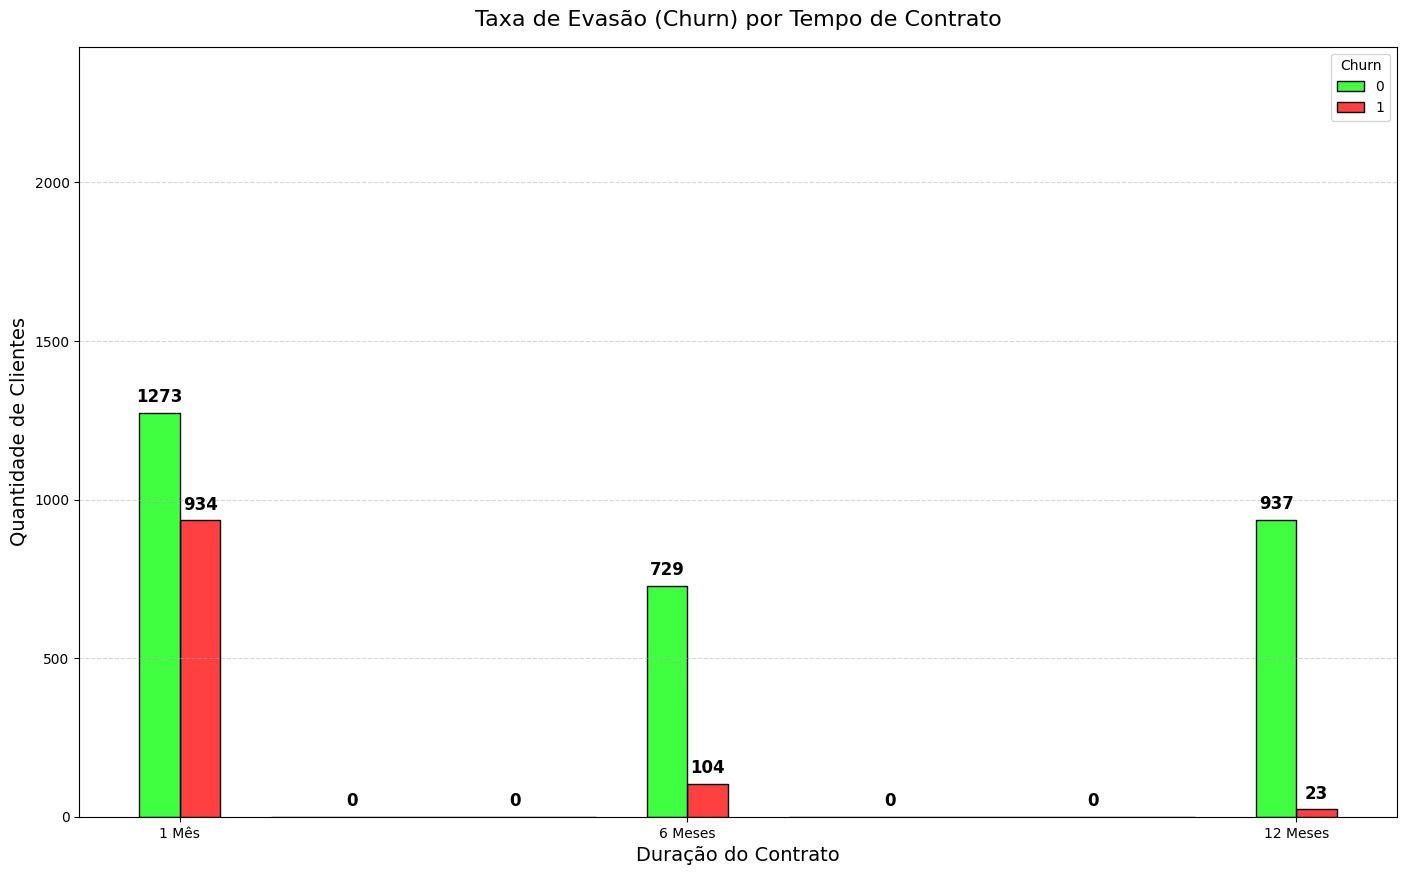

In [ ]:
plt.figure(figsize=(17, 10))

# 1. Armazenamos o gráfico na variável 'ax' para conseguir acessar as barras depois
ax = sns.histplot(
    data=data,
    x='Contract_period',
    hue='Churn',
    multiple='dodge',  # Deixa as barras de Churn (0 e 1) lado a lado
    bins=[0.5, 1.5, 5.5, 6.5, 11.5, 12.5],  # Cria os 3 "bins" isolando os meses
    shrink=0.8,        # Separa visualmente os 3 blocos de meses
    palette=palette
)

# 2. Loop automático que passa por cada grupo de barras (Churn 0 e Churn 1) e coloca os números
for container in ax.containers:
    ax.bar_label(
        container,
        padding=5,         # Pequeno espaço em pixels entre o topo da barra e o texto
        fontsize=12,       # Tamanho da fonte do número
        weight='bold'      # Deixa o número em negrito para facilitar a leitura
    )

# Força o eixo X a mostrar apenas os meses corretos do contrato
plt.xticks([1, 6, 12], ['1 Mês', '6 Meses', '12 Meses'])

plt.title('Taxa de Evasão (Churn) por Tempo de Contrato', fontsize=16, pad=15)
plt.xlabel('Duração do Contrato', fontsize=14)
plt.ylabel('Quantidade de Clientes', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Aumenta um pouco o limite do eixo Y para os números do topo não cortarem na borda do gráfico
plt.ylim(0, data['Contract_period'].value_counts().max() * 1.1)

plt.show()

Neste histograma, alunos com tempo de contrato igual ou inferiores a um mês tendem a abandonar a academia com mais facilidade, enquanto contratos mais longos de 6 meses a 1 ano tendem a reter os alunos que são mais fiéis, resultando em evasões mais baixas nesses pontos.

A duração menos previsível é a de 6 meses demonstrando o perfil dos alunos que ou já permanecem em um plano de 12 meses ou mantém o plano de um mês, e que geralmente alegam fazer isso pra evitar rompimento de contrato caso queiram cancelar.

A quantidade total de alunos que assinam contratos curtos chega a ser mais de de 40% em média maior do que os demais, sendo uma importante fonte de receita para a academia.

Na duração de um mês a evasão é catastrófica, mais de 40%, quase metade dos clientes que entram no plano mensal desistem imediatamente. Este plano serve apenas como uma "porta giratória".

### 2.3) Gráfico de Distribuição da Idade

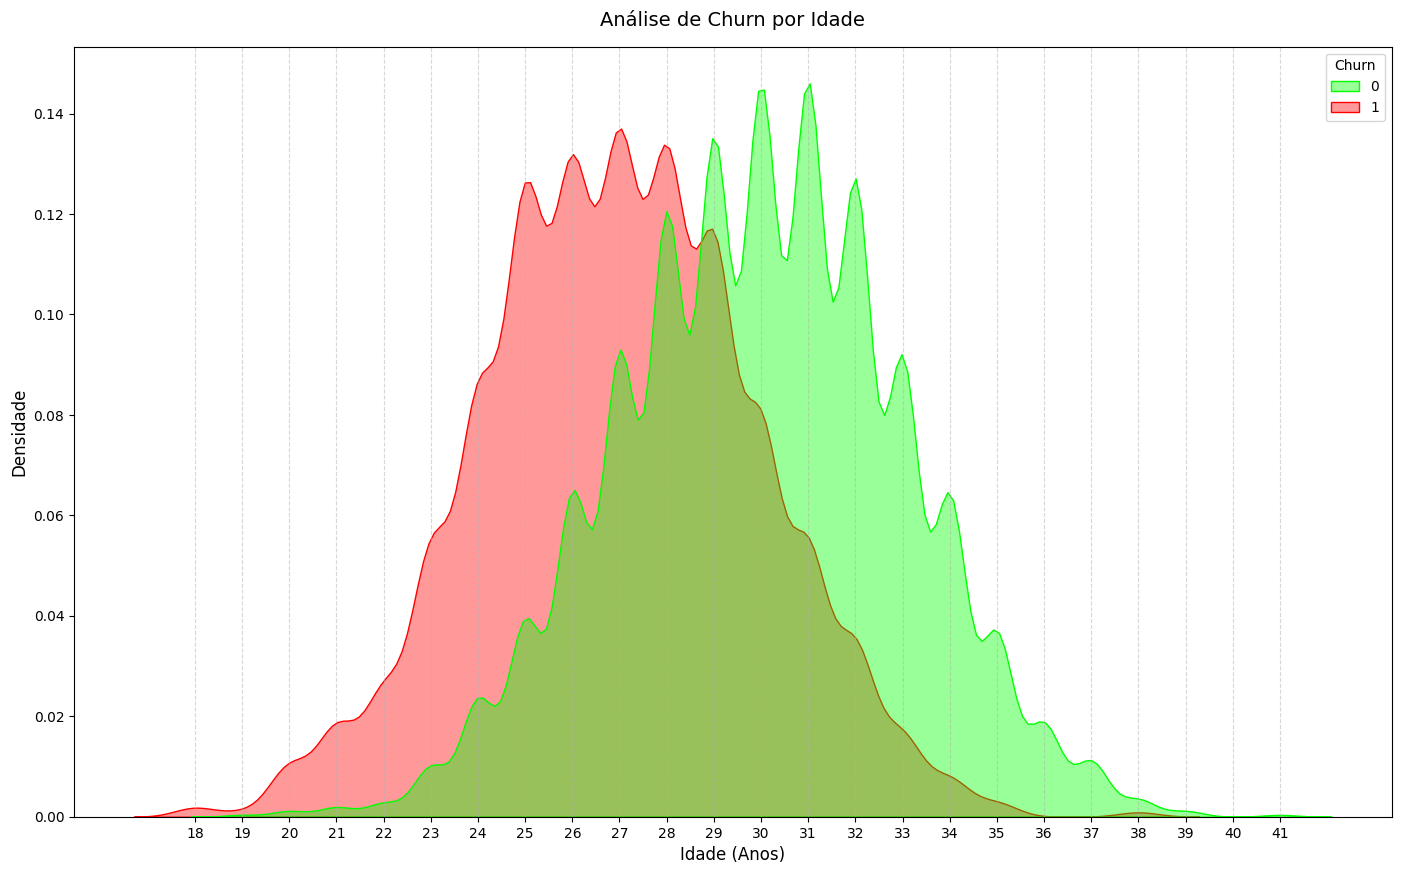

In [ ]:
# 2. Definir um tamanho de figura mais largo para os anos não ficarem espremidos
plt.figure(figsize=(17, 10))

# 3. Criar o KDE Plot
sns.kdeplot(
    data=data,
    x='Age',
    hue='Churn',
    fill=True,
    common_norm=False,
    palette=palette,
    alpha=0.4,
    bw_adjust=0.6  # Torna a curva mais sensível para capturar as variações ano a ano
)

# 4. Configurar o eixo X para ir de 18 a 41, pulando de 1 em 1
# O stop no range é 42 porque o último número é exclusivo
plt.xticks(range(18, 42, 1))

# Configurações visuais de suporte
plt.title('Análise de Churn por Idade', fontsize=14, pad=15)
plt.xlabel('Idade (Anos)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)

# Adiciona linhas verticais tracejadas em cada ano para facilitar a leitura pontual
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

Neste gráfico, pessoas entre 24 e 30 anos são mais propensas a cancelar contratos, enquanto aquelas acima dos 30 são mais fiéis ao ambiente. A academia falha terrivelmente em engajar o público jovem. Eles são mais voláteis, provavelmente possuem rotinas menos estáveis e exigem um acompanhamento de integração (onboarding) muito mais agressivo do que o público maduro. Alguns fatores psicólógicos e sociais podem explicar esse fator, como a busca por novidades, a maior facilidade dos concorrentes em seduzir jovens, a instabilidade financeira e a possibilidade de mudanças drásticas no início da vida adulta (mudança de cidade, mudança de emprego, aquisição de família e outras responsabilidades).

### 2.4) Histograma de gastos

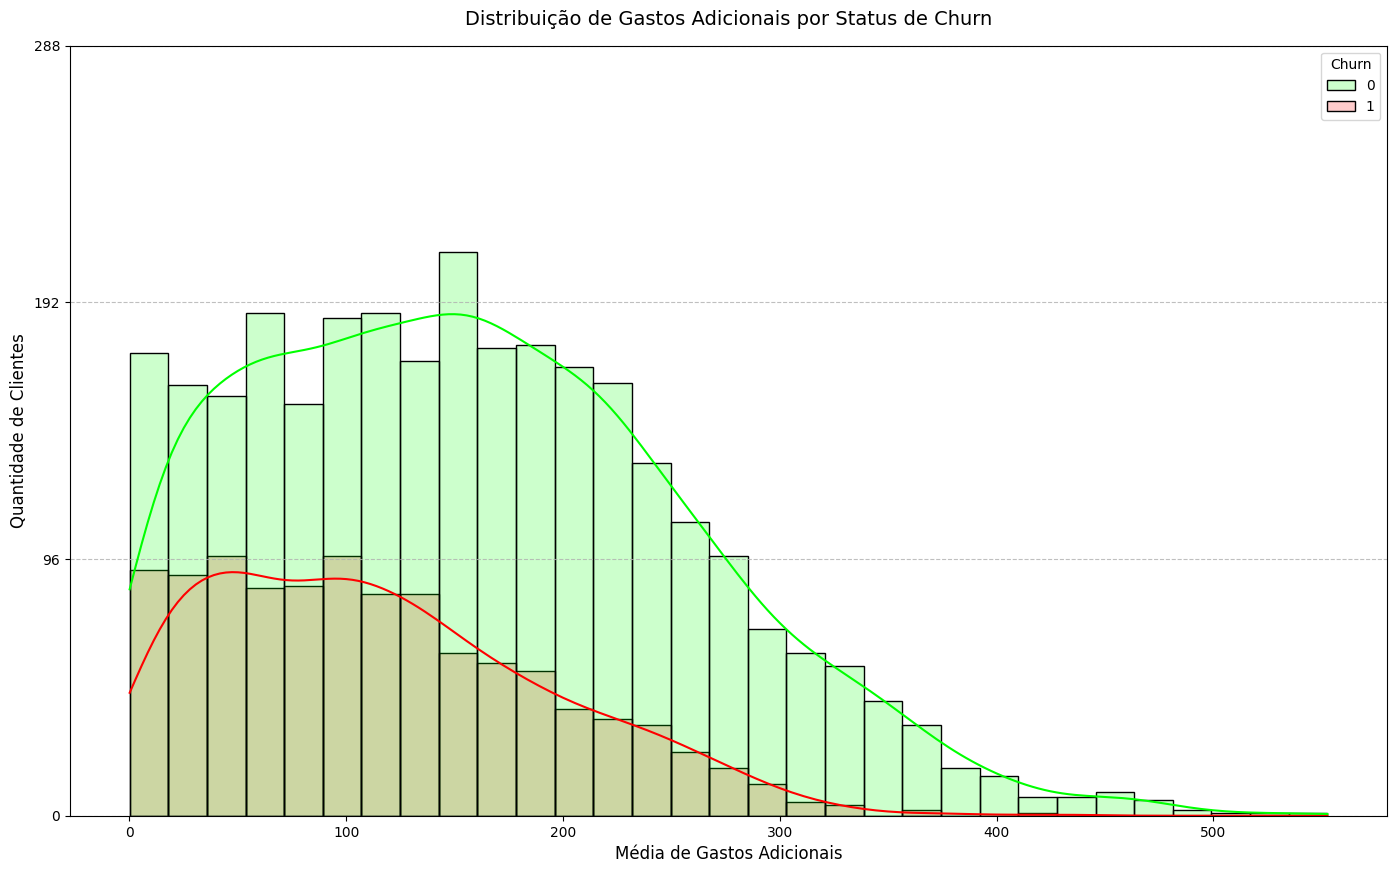

In [ ]:
# 1. Criar a figura e o eixo
fig, ax = plt.subplots(figsize=(17, 10))


# 2. Plotar usando histplot com kde=True para habilitar o eixo de contagem
sns.histplot(
    data=data,
    x='Avg_additional_charges_total',
    hue='Churn',
    kde=True,             # Ativa a curva suave do KDE
    alpha=0.2,            # Deixa as barras de fundo bem sutis para destacar a curva
    palette=palette,
    ax=ax
)

# 3. Pegar o limite máximo automático que o eixo Y alcançou
limite_superior = int(ax.get_ylim()[1])

# 4. Criar a lista de marcações pulando de 96 em 96
valores_y = list(range(0, limite_superior + 96, 96))
ax.set_yticks(valores_y)

# Customizações de layout
plt.title('Distribuição de Gastos Adicionais por Status de Churn', fontsize=14, pad=15)
plt.xlabel('Média de Gastos Adicionais', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

# Adiciona linhas de grade horizontais alinhadas com os 96 pontos
plt.grid(axis='y', linestyle='--', alpha=0.8)

plt.show()

Aqui neste gráfico, a imensa maioria dos clientes que evadem concentram seus gastos acumulados na faixa de R$ 0 a RS 100. Essa variável apresentou uma correlação negativa baixa em relação à evasão, mas é interessante notar que clientes com menor gasto tendem a não permanecer.

Algumas hipóteses a serem levantadas, pode ser que a assinatura foi para conhecer o ambiente e por isso optou-se por um plano mais barato, ou as atividades ofertadas não eram do agrado desses clientes e abandonaram o serviço.

O gasto extra é um excelente indicador de pertencimento. O cliente que compra um suplemento, uma água ou paga por um serviço extra vê valor no ecossistema da academia. Quem não gasta nada extra, já está com um pé fora da empresa.

### 2.5) Gráfico de distribuição dos Meses Restantes até o Fim do Contrato

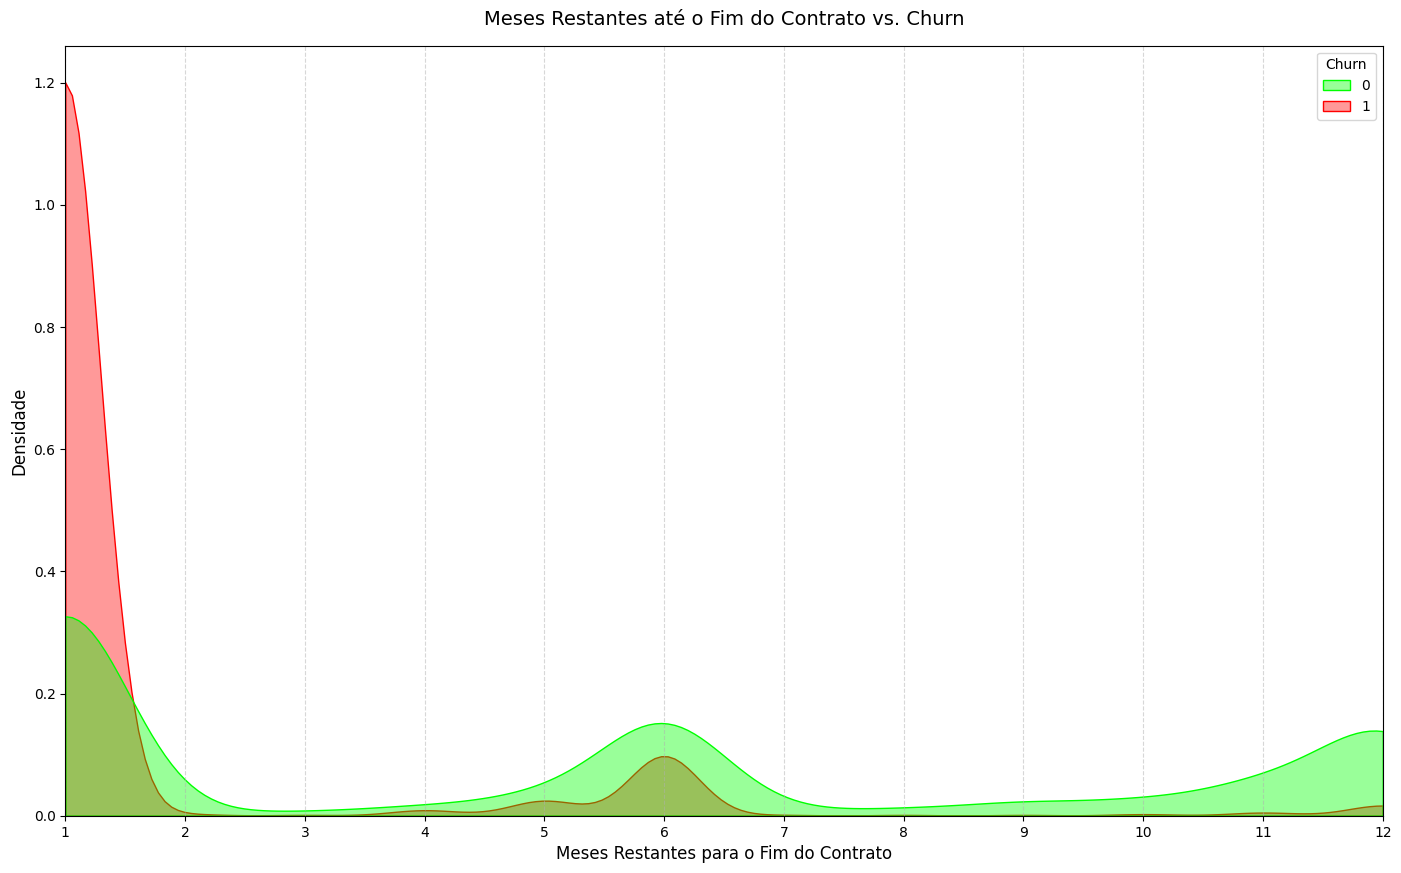

In [ ]:
# 2. Configurar o tamanho da tela
plt.figure(figsize=(17, 10))


# 3. Criar o KDE Plot
sns.kdeplot(
    data=data,
    x='Month_to_end_contract',
    hue='Churn',
    fill=True,
    common_norm=False,
    palette=palette,
    alpha=0.4,
    bw_adjust=0.6,       # Ajusta a sensibilidade para pegar os picos dos meses exatos
    clip=(1, 12)         # Corta a curva rigorosamente entre os meses 1 e 12
)

# 4. Forçar o eixo X a ir de 1 a 12, pulando de 1 em 1
# O stop é 13 porque o limite superior do range é exclusivo
plt.xticks(range(1, 13, 1))
plt.xlim(1, 12)

# Customizações visuais
plt.title('Meses Restantes até o Fim do Contrato vs. Churn', fontsize=14, pad=15)
plt.xlabel('Meses Restantes para o Fim do Contrato', fontsize=12)
plt.ylabel('Densidade', fontsize=12)

# Linhas de grade verticais em cada mês para facilitar a leitura
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

Aqui é notável, e faz bastante sentido do ponto de vista comportamental que a grande maioria das pessoas deixa de ir quando falta um mês ou menos para o encerramento do contrato. Com uma leve curva em torno dos 6 meses também.

Esperar o último mês para tentar renovar com o cliente é um erro fatal. A jornada de renovação precisa começar meses antes, principalmente para quem está no plano semestral.

### 2.6) Gráfico de distribuição de tempo de permanência na Academia

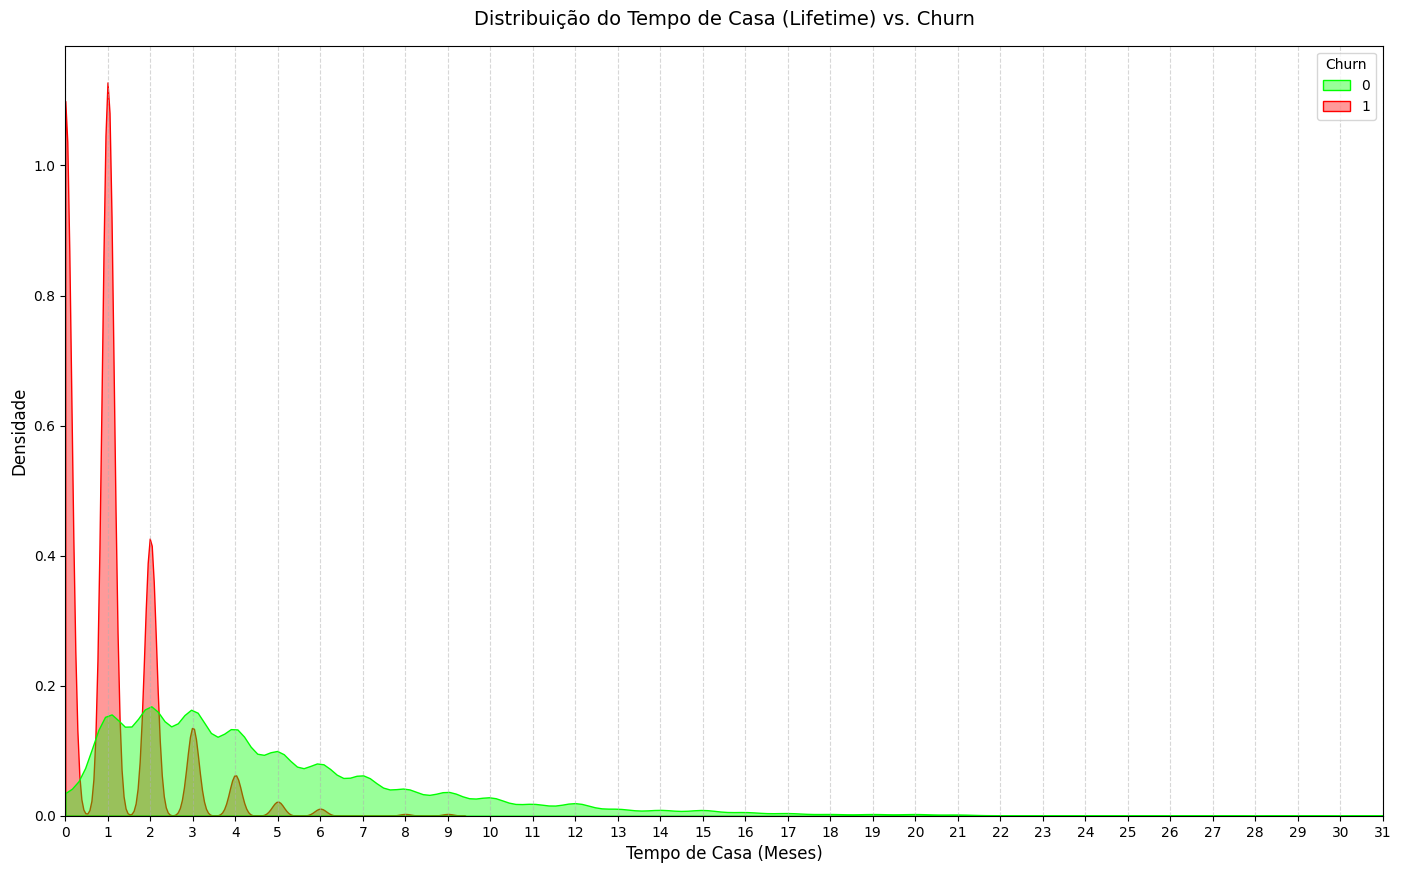

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 2. Configurar o tamanho da figura para acomodar os 30 ticks no eixo X
# Uma largura maior ajuda a não encavalar os números.
plt.figure(figsize=(17, 10))


# 3. Criar o KDE Plot
sns.kdeplot(
    data=data,
    x='Lifetime',
    hue='Churn',
    fill=True,
    common_norm=False,
    palette=palette,
    alpha=0.4,
    bw_adjust=0.5,       # Ajuste fino para capturar variações mês a mês
    clip=(0, 31)         # Garante que a densidade não "vaze" além de 0 ou 29
)

# 4. Configurar o eixo X de 0 a 29, pulando de 1 em 1
# O stop no range é 30 porque o último número é exclusivo.
plt.xticks(range(0, 32, 1))
plt.xlim(0, 31)

# Customizações visuais
plt.title('Distribuição do Tempo de Casa (Lifetime) vs. Churn', fontsize=14, pad=15)
plt.xlabel('Tempo de Casa (Meses)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)

# Adiciona linhas de grade verticais em cada mês para facilitar a leitura
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

Ainda nessa mesma temática de meses de contrato, há um pico de abandono em torno de 0 e 2 meses. Superando esse período inicial, o aluno tende a permanecer, e quanto mais longo o período de presença, menor tende a ser a evasão.

A academia tem um vale na recepção. O atendimento falha em acompanhar o aluno novato no momento mais crítico: **o início**, quando ele ainda não criou o hábito de treinar.

### 2.7) Frequência Semanal no Último Mês

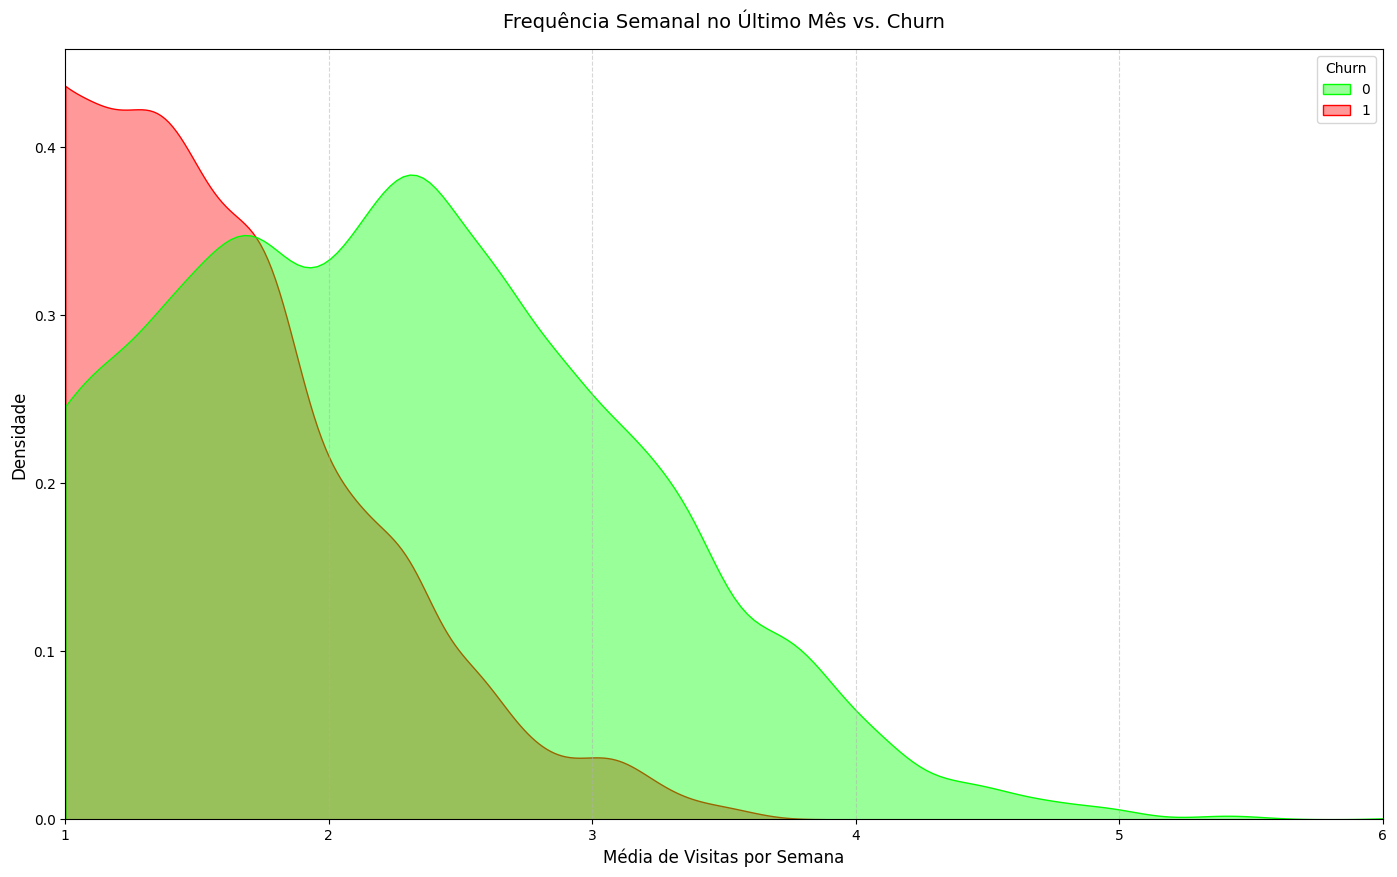

In [ ]:
# 2. Configurar o tamanho da figura
plt.figure(figsize=(17, 10))


# 3. Criar o KDE Plot
sns.kdeplot(
    data=data,
    x='Avg_class_frequency_current_month',
    hue='Churn',
    fill=True,
    common_norm=False,
    palette=palette,
    alpha=0.4,
    bw_adjust=0.6,       # Mantém a curva suave, mas precisa para os picos de frequência
    clip=(1, 6)          # Garante que as caudas do KDE não passem de 1 ou 6
)

# 4. Configurar o eixo X de 1 a 6, de 1 em 1
# O stop é 7 porque o limite superior do range é exclusivo
plt.xticks(range(1, 7, 1))
plt.xlim(1, 6)

# Customizações visuais
plt.title('Frequência Semanal no Último Mês vs. Churn', fontsize=14, pad=15)
plt.xlabel('Média de Visitas por Semana', fontsize=12)
plt.ylabel('Densidade', fontsize=12)

# Linhas de grade verticais para marcar cada dia de treino
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

Já aqui é notável, e faz bastante sentido, que a frequência semanal seja reduzida de 1 a 2 treinos por semana para quem deixa de frequentar a academia. O que sinaliza para baixo interesse naquela atividade específica, ou alguma outra dificuldade na vida do aluno, aumentando o índice de evasão. Um cliente que costumava ir 3 vezes ou mais na semana e cai para 2, 1 ou 0 é um alerta vermelho pro negócio. A ausência física é o sintoma que antecede o cancelamento contratual.

### 2.8) Gráfico Comparativo da Importância de Atributo

In [ ]:
# Comparando a frequência do mês atual com a frequência histórica (total)
data['Frequencia_ATUAL_menos_TOTAL'] = data['Avg_class_frequency_current_month'] - data['Avg_class_frequency_total']

# Indicador (0/1) para destacar casos onde a frequência caiu no mês atual
data['Frequencia_Caiu'] = (data['Frequencia_ATUAL_menos_TOTAL'] < 0).astype(int)

# Indicador (0/1) para destacar casos com frequência zero no mês atual
data['Sem_Frequencia_no_Mes_Atual'] = (data['Avg_class_frequency_current_month'] == 0).astype(int)

# Isso pode destacar alguns usuários que nunca se comprometeram totalmente
data['Esforco_Total_Academia'] = data['Avg_class_frequency_total'] * data['Lifetime']

# Mais laços sociais (desconto corporativo, indicação de amigos, aulas em grupo) podem criar maior engajamento comunitário
data['Pontuacao_Social'] = data['Partner'] + data['Promo_friends'] + data['Group_visits']

# Membros mais velhos com baixa frequência podem ter maior probabilidade de desistir por saúde
data['Idade_x_Frequencia'] = data['Age'] * data['Avg_class_frequency_current_month']

# Se eles moram perto e têm baixa frequência, isso pode ser um mau sinal (sinal de alerta)
data['Localizacao_x_Frequencia'] = data['Near_Location'] * data['Avg_class_frequency_current_month']

# Novatos e clientes com baixa frequência são os mais propensos a sair; isto ajuda a capturar esse padrão
data['Tempo_casa_x_Frequencia'] = data['Lifetime'] * data['Avg_class_frequency_current_month']

In [ ]:
best = {'depth': 5.0, 'iterations': 200.0, 'l2_leaf_reg': 9.918629263328938, 'learning_rate': 0.07777702998362673}

X = data.drop(columns=target_col)
y = data[target_col]

In [ ]:
# Train final model with best parameters
best_model = CatBoostClassifier(
    depth=int(best['depth']),
    learning_rate=best['learning_rate'],
    l2_leaf_reg=best['l2_leaf_reg'],
    iterations=int(best['iterations']),
    random_state=42,
    verbose=0,
    cat_features=cat_cols
)

# K-Fold Cross Validation
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
cv_scores = []

for train_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    best_model.fit(X_tr, y_tr)
    score = best_model.score(X_val, y_val)
    cv_scores.append(score)

# Display Cross Validation results
print(f"Pontuações da Validação-Cruzada: {cv_scores}")
print(f"Pontuação Média da CV: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores) * 2:.4f})")

Pontuações da Validação-Cruzada: [np.float64(0.9525), np.float64(0.9675), np.float64(0.95625), np.float64(0.9625), np.float64(0.96125)]
Pontuação Média da CV: 0.9600 (+/- 0.0104)


/tmp/ipykernel_2510/1032020965.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Atributo', data=feature_importance, palette='husl')


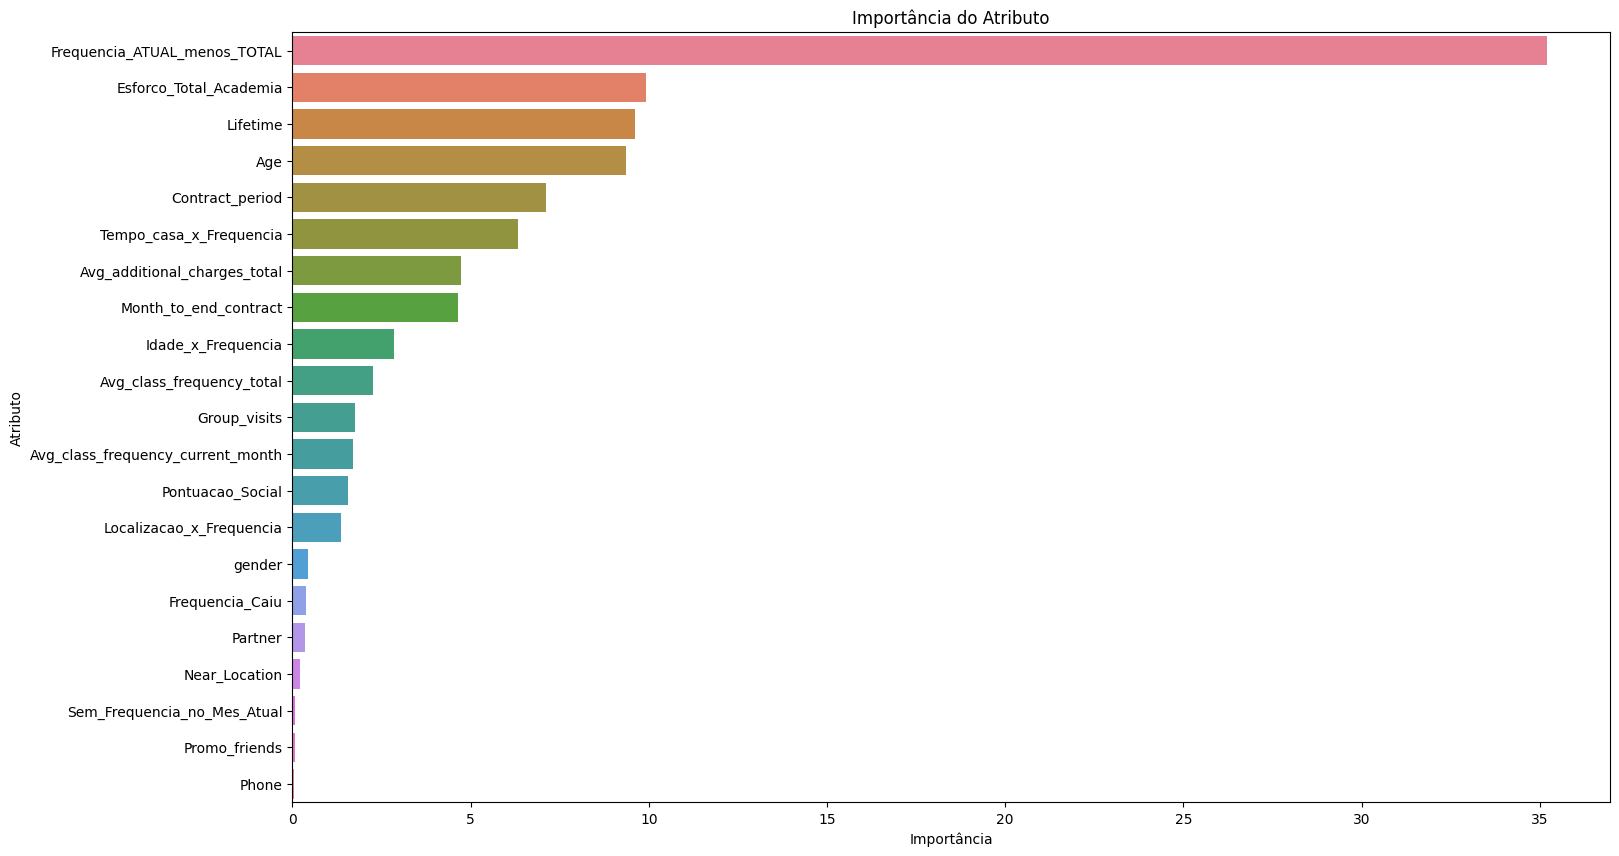

In [ ]:
# Feature Importances
feature_importance = pd.DataFrame({
    'Atributo': X_tr.columns,
    'Importância': best_model.get_feature_importance()
}).sort_values('Importância', ascending=False)

plt.figure(figsize=(17, 10))
sns.barplot(x='Importância', y='Atributo', data=feature_importance, palette='husl')
plt.title('Importância do Atributo')
plt.show()

Por último, esse gráfico mostra quais atributos tem mais impacto na evasão:

1. O primeiro atributo se torna o mais importante porque quanto mais o aluno permanece na academia, mais engajado e motivado ele está nas atividades, diminuindo bastante a chance de evasão.

2. Já o esforço total entra em segundo lugar, pois é a medida da quantidade de treinos semanal por mês vezes a quantidade de meses persistida na academia, demonstrando que quem mais fica na academia ao longo do tempo menos evade.

3. O terceiro, é o tempo de permanência mensal, que também conta da mesma forma.

4. E em quarto, a idade, onde jovens são mais propensos a saírem do que pessoas com mais de 30 anos.

### 2.9) Decision Tree Analysis

In [ ]:
# ============================================================
# Decision Tree Analysis + Comparação CatBoost
# Versão 1: Features Originais
# Versão 2: Features Originais + Engineered
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, f1_score,
    ConfusionMatrixDisplay
)

# ── Paleta do projeto ────────────────────────────────────────
PALETTE = {0: '#00C853', 1: '#D50000'}
COLOR_TREE_V1  = '#1565C0'
COLOR_TREE_V2  = '#6A1B9A'
COLOR_CATBOOST = '#E65100'

# ============================================================
# 0. CARREGAMENTO E PRÉ-PROCESSAMENTO
# ============================================================
data = pd.read_csv('/content/gym_churn_us.csv')

# Colunas originais
num_cols = [
    'Contract_period', 'Age', 'Avg_additional_charges_total',
    'Month_to_end_contract', 'Lifetime',
    'Avg_class_frequency_total', 'Avg_class_frequency_current_month'
]
cat_cols = ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Group_visits']
target_col = 'Churn'

# ── Feature Engineering (mesmo do notebook original) ────────
data['Frequencia_ATUAL_menos_TOTAL'] = (
    data['Avg_class_frequency_current_month'] - data['Avg_class_frequency_total']
)
data['Frequencia_Caiu']              = (data['Frequencia_ATUAL_menos_TOTAL'] < 0).astype(int)
data['Sem_Frequencia_no_Mes_Atual']  = (data['Avg_class_frequency_current_month'] == 0).astype(int)
data['Esforco_Total_Academia']       = data['Avg_class_frequency_total'] * data['Lifetime']
data['Pontuacao_Social']             = data['Partner'] + data['Promo_friends'] + data['Group_visits']
data['Idade_x_Frequencia']          = data['Age'] * data['Avg_class_frequency_current_month']
data['Localizacao_x_Frequencia']    = data['Near_Location'] * data['Avg_class_frequency_current_month']
data['Tempo_casa_x_Frequencia']     = data['Lifetime'] * data['Avg_class_frequency_current_month']

eng_cols = [
    'Frequencia_ATUAL_menos_TOTAL', 'Frequencia_Caiu',
    'Sem_Frequencia_no_Mes_Atual', 'Esforco_Total_Academia',
    'Pontuacao_Social', 'Idade_x_Frequencia',
    'Localizacao_x_Frequencia', 'Tempo_casa_x_Frequencia'
]

# ── Conjuntos de features ────────────────────────────────────
X_v1 = data[num_cols + cat_cols]          # só originais
X_v2 = data[num_cols + cat_cols + eng_cols]  # originais + engineered
y    = data[target_col]

X_v1_train, X_v1_test, y_train, y_test = train_test_split(
    X_v1, y, test_size=0.2, random_state=42, stratify=y
)
X_v2_train, X_v2_test, _, _ = train_test_split(
    X_v2, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 1. DECISION TREE — Versão 1 (features originais)
# ============================================================
dt_v1 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=42
)
dt_v1.fit(X_v1_train, y_train)
y_pred_v1 = dt_v1.predict(X_v1_test)

# ============================================================
# 2. DECISION TREE — Versão 2 (originais + engineered)
# ============================================================
dt_v2 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=42
)
dt_v2.fit(X_v2_train, y_train)
y_pred_v2 = dt_v2.predict(X_v2_test)

# ============================================================
# 3. CATBOOST (parâmetros do notebook original)
# ============================================================
best = {
    'depth': 5, 'iterations': 200,
    'l2_leaf_reg': 9.918629263328938,
    'learning_rate': 0.07777702998362673
}
cb_model = CatBoostClassifier(
    depth=int(best['depth']),
    learning_rate=best['learning_rate'],
    l2_leaf_reg=best['l2_leaf_reg'],
    iterations=int(best['iterations']),
    random_state=42, verbose=0,
    cat_features=cat_cols
)
cb_model.fit(X_v2_train, y_train)
y_pred_cb = cb_model.predict(X_v2_test)

# ============================================================
# 4. CROSS-VALIDATION (5-fold) — todas as métricas
# ============================================================
def cv_metrics(model, X, y, cat=False):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    accs, f1s, rocs = [], [], []
    for tr, val in kf.split(X):
        Xtr, Xval = X.iloc[tr], X.iloc[val]
        ytr, yval = y.iloc[tr], y.iloc[val]
        model.fit(Xtr, ytr)
        pred = model.predict(Xval)
        accs.append(accuracy_score(yval, pred))
        f1s.append(f1_score(yval, pred))
        try:
            prob = model.predict_proba(Xval)[:, 1]
            rocs.append(roc_auc_score(yval, prob))
        except:
            rocs.append(np.nan)
    return {
        'Accuracy': (np.mean(accs), np.std(accs)),
        'F1-Score': (np.mean(f1s), np.std(f1s)),
        'ROC-AUC':  (np.mean(rocs), np.std(rocs)),
    }

print("Calculando CV — DT v1...")
cv_v1 = cv_metrics(
    DecisionTreeClassifier(max_depth=5, min_samples_leaf=30,
                           class_weight='balanced', random_state=42),
    X_v1, y
)
print("Calculando CV — DT v2...")
cv_v2 = cv_metrics(
    DecisionTreeClassifier(max_depth=5, min_samples_leaf=30,
                           class_weight='balanced', random_state=42),
    X_v2, y
)
print("Calculando CV — CatBoost...")
cv_cb = cv_metrics(
    CatBoostClassifier(depth=5, learning_rate=best['learning_rate'],
                       l2_leaf_reg=best['l2_leaf_reg'], iterations=200,
                       random_state=42, verbose=0, cat_features=cat_cols),
    X_v2, y
)

Calculando CV — DT v1...
Calculando CV — DT v2...
Calculando CV — CatBoost...


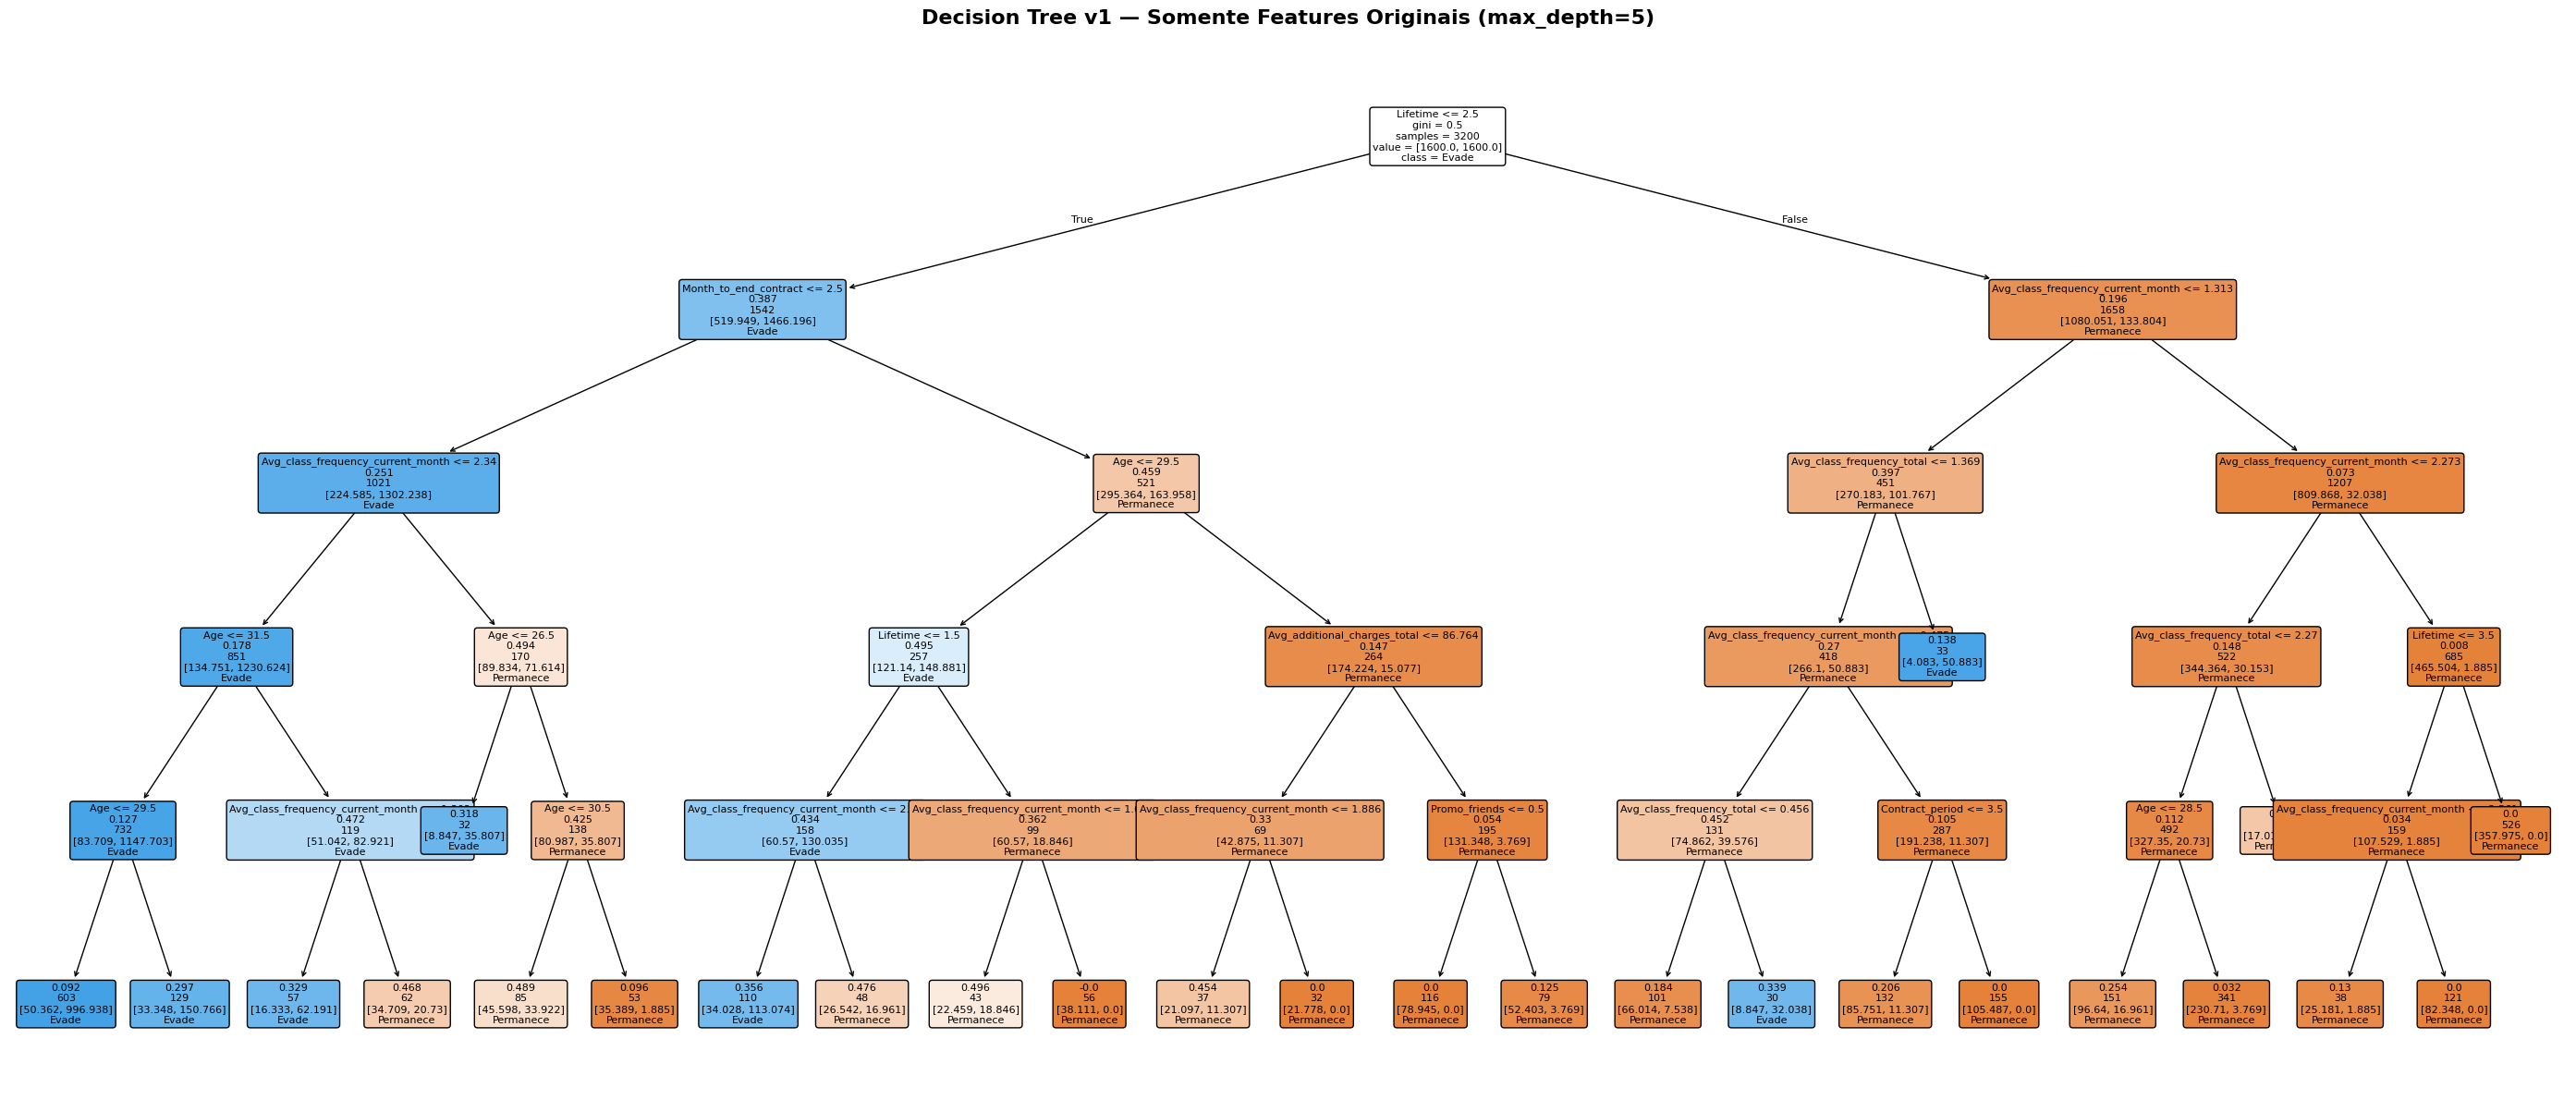

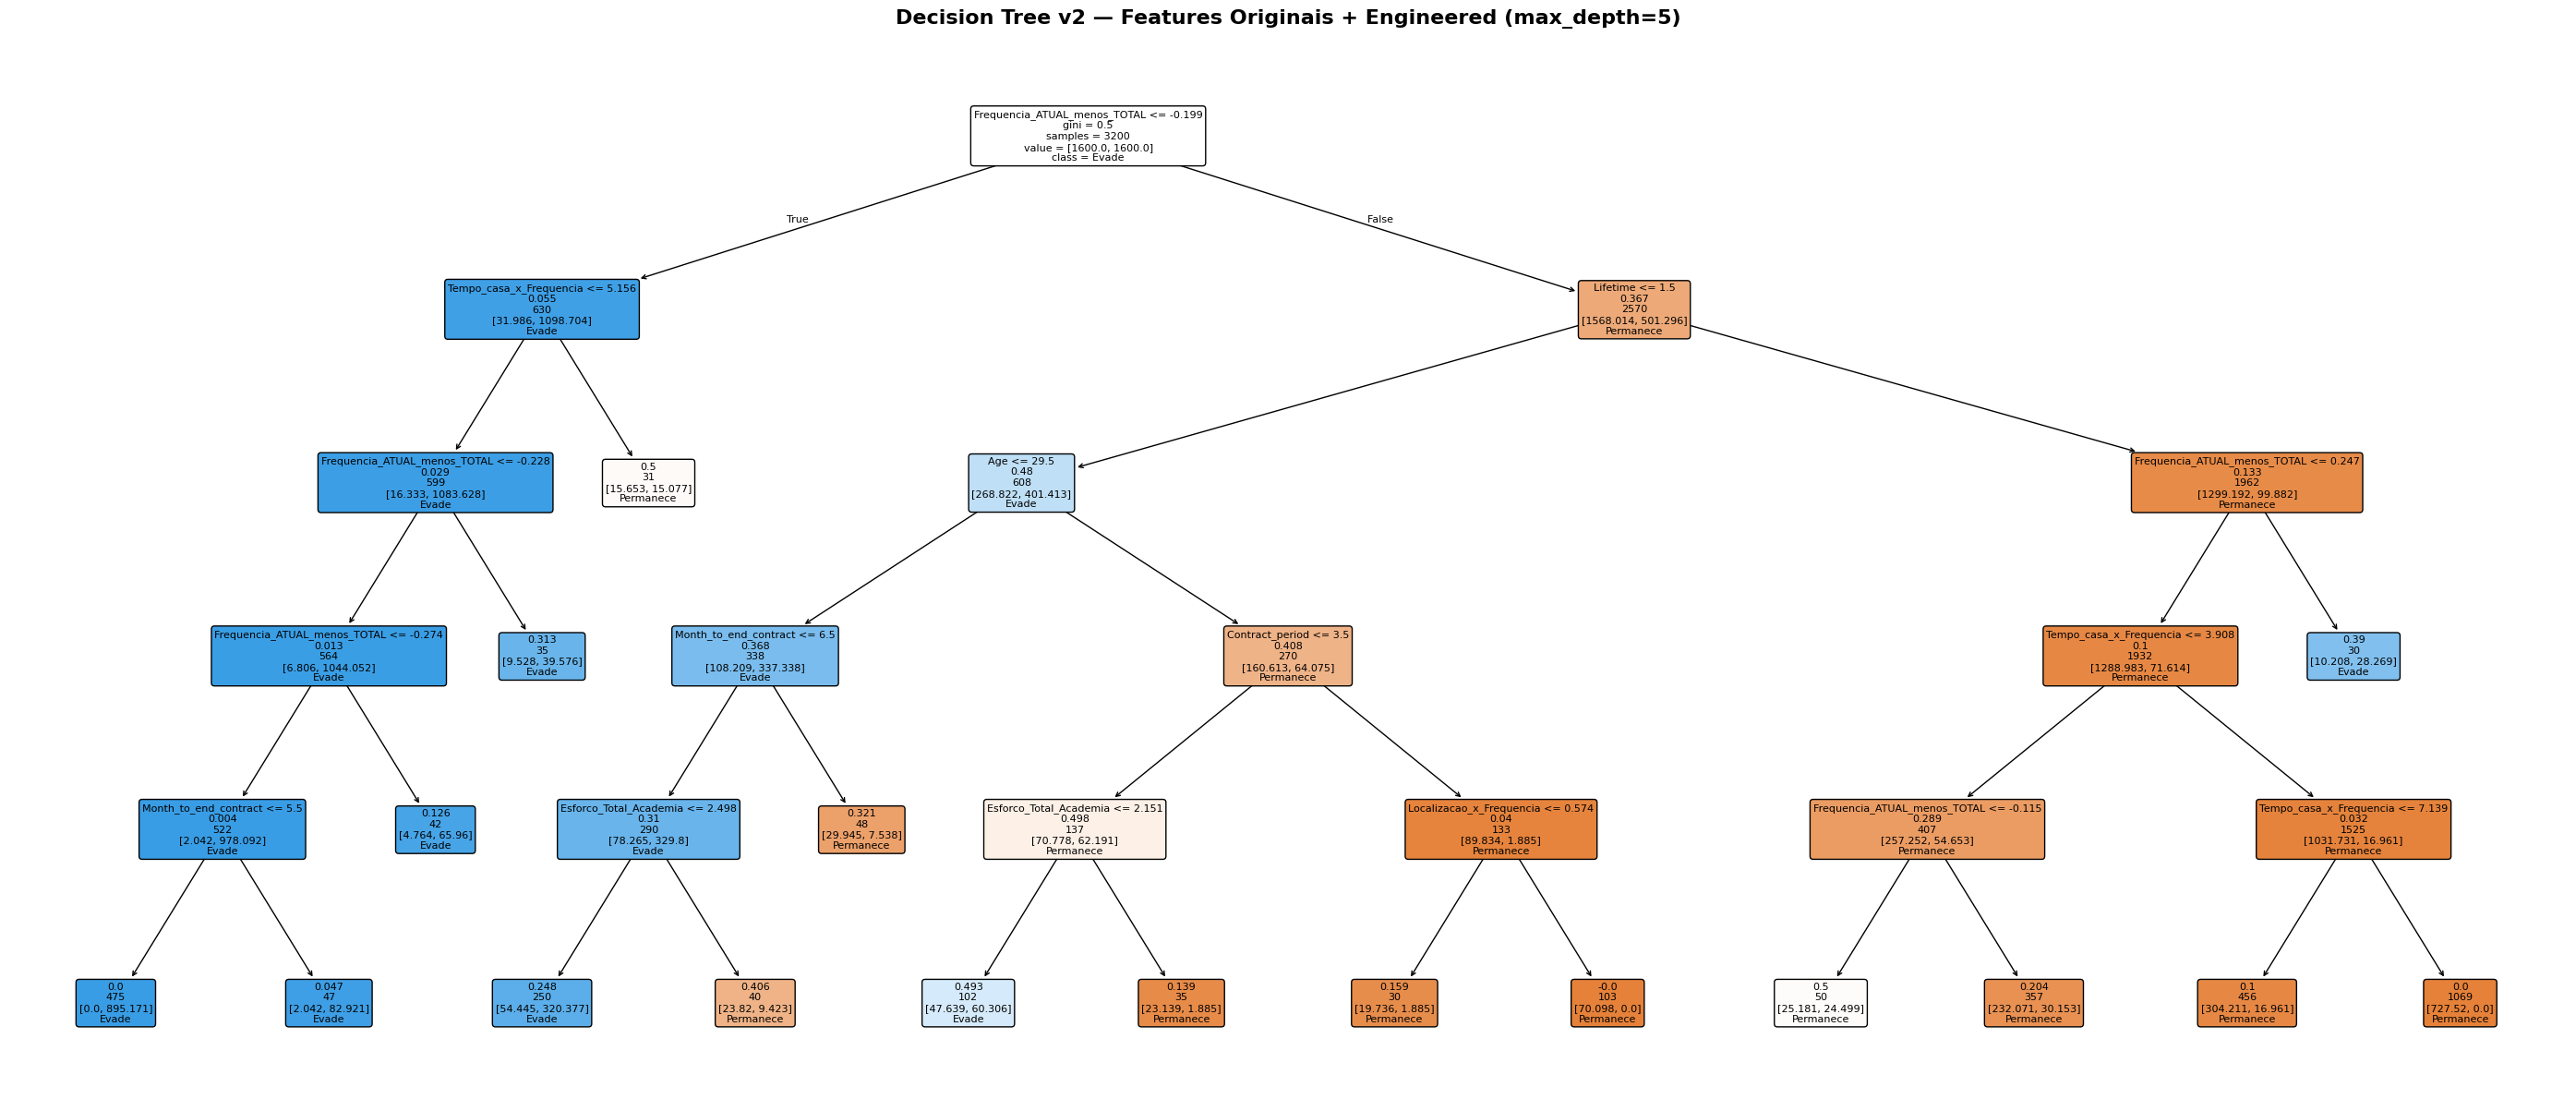

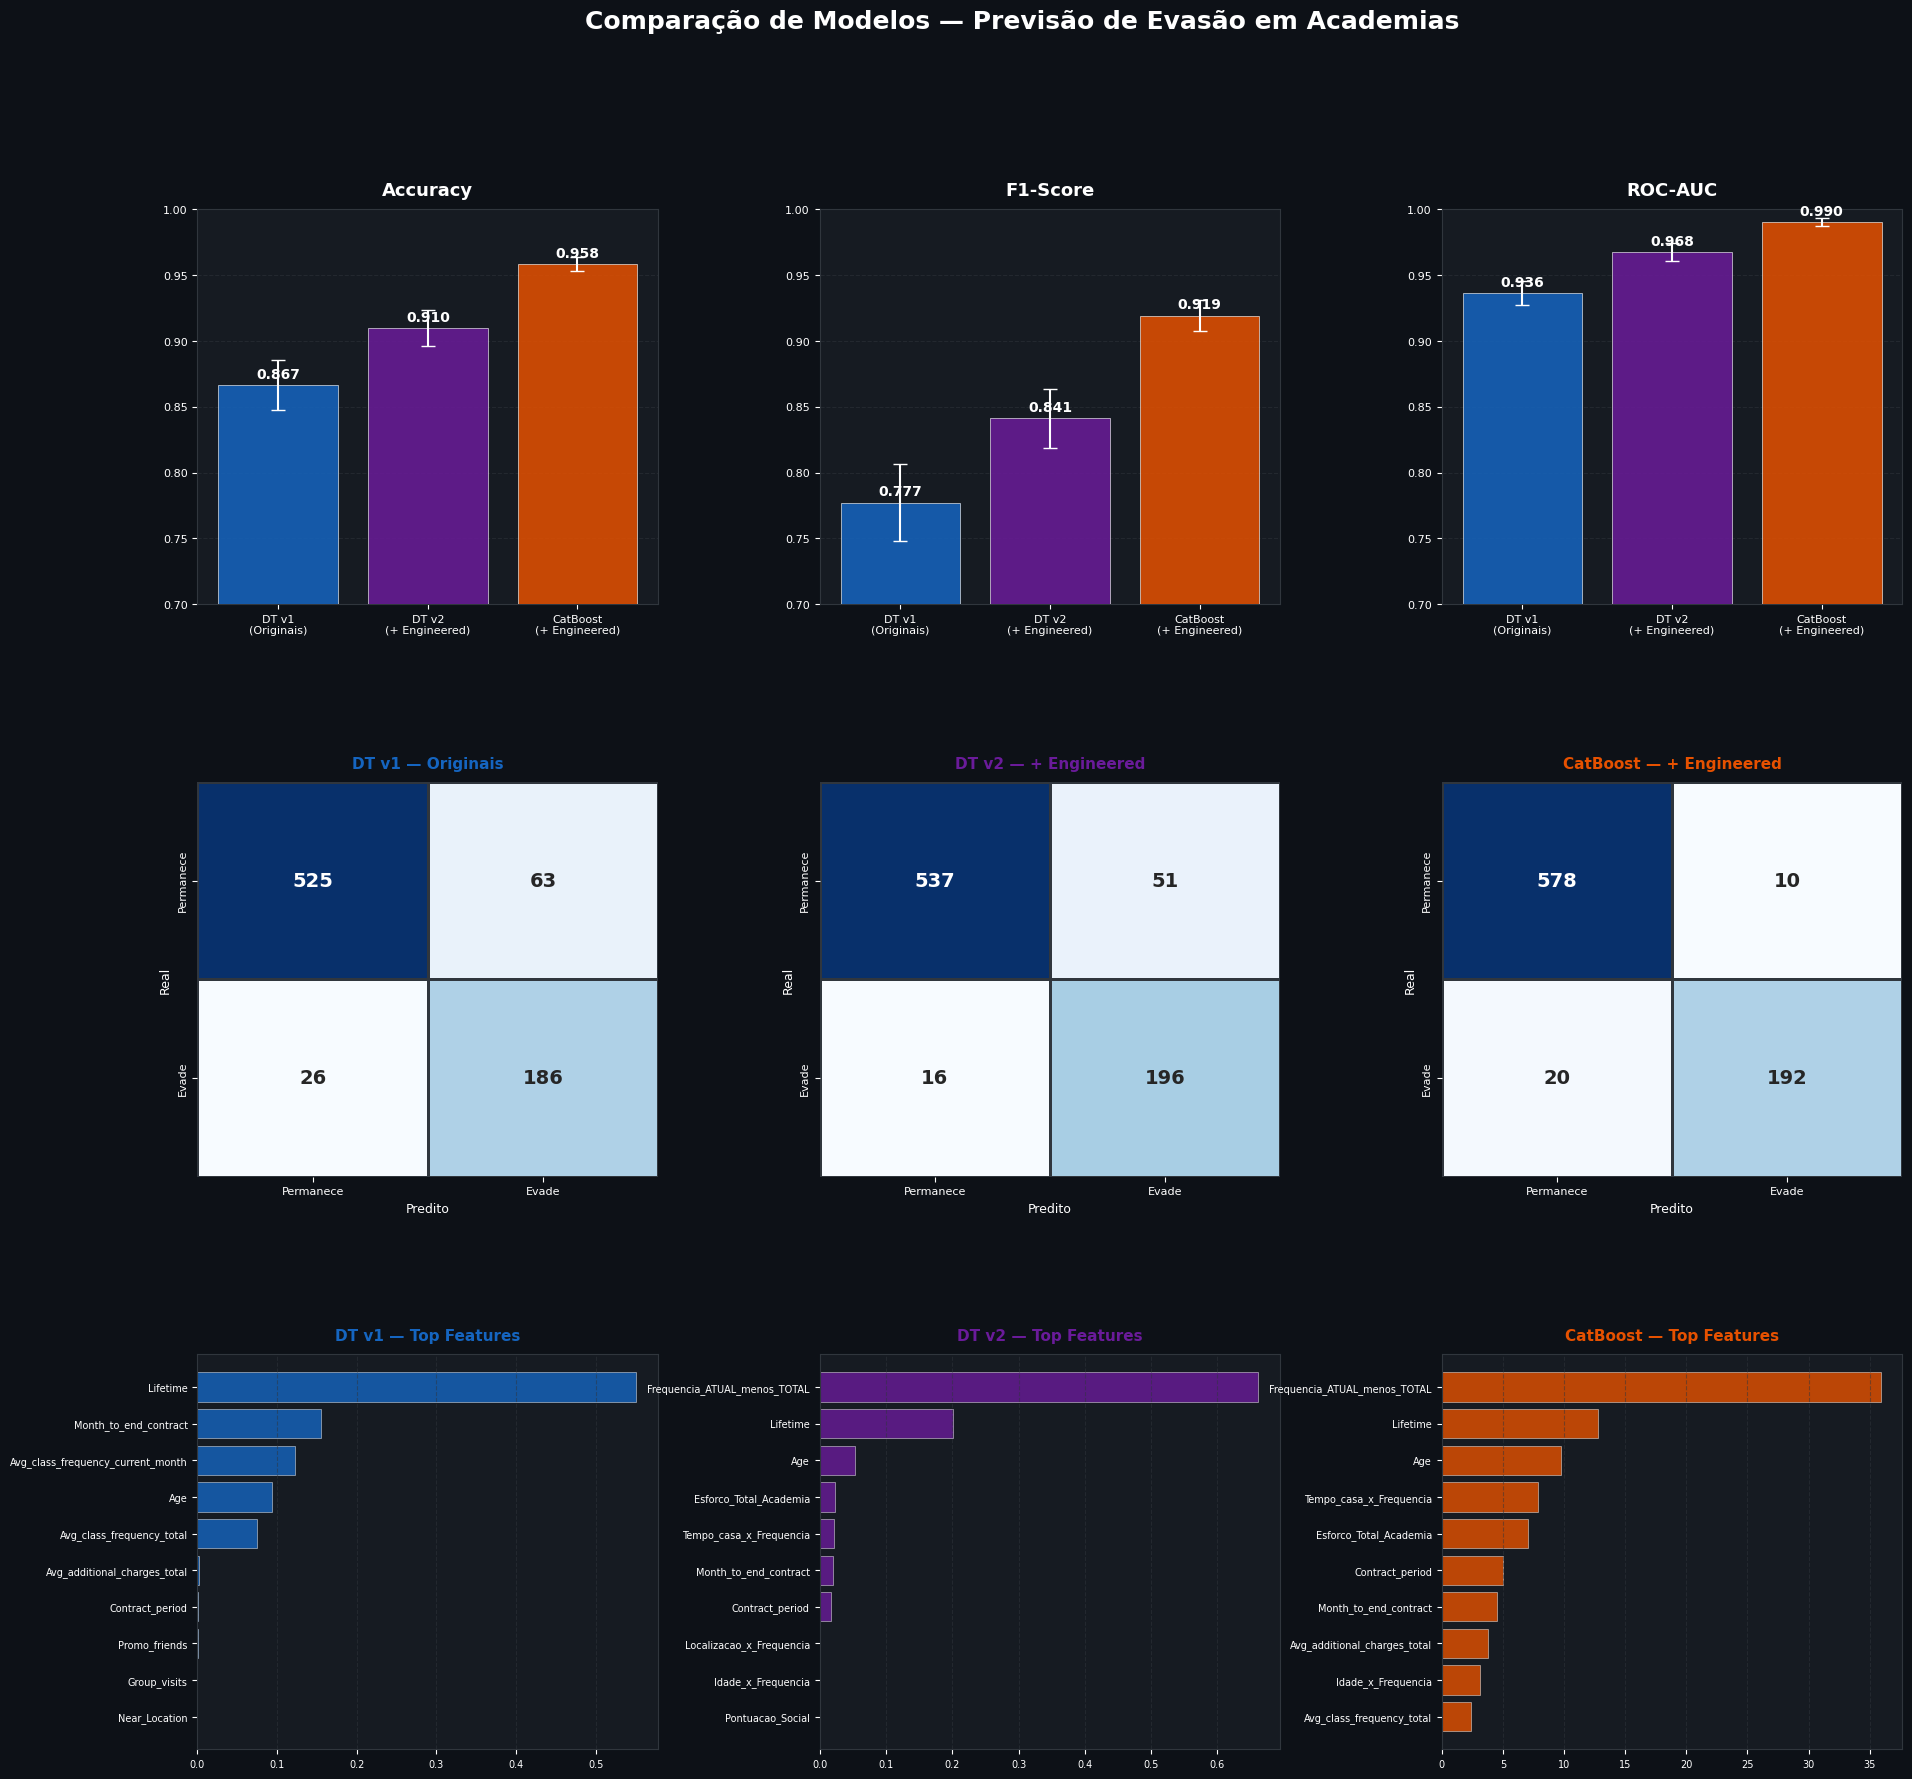


COMPARAÇÃO FINAL — CROSS-VALIDATION 5-FOLD
Modelo                        Accuracy     F1-Score      ROC-AUC
----------------------------------------------------------------------
DT v1 (Originais)          0.867±0.019  0.777±0.029  0.936±0.009
DT v2 (+ Engineered)       0.910±0.013  0.841±0.023  0.968±0.007
CatBoost (+ Engineered)    0.958±0.005  0.919±0.012  0.990±0.003

── DT v1 (Originais) ──
              precision    recall  f1-score   support

   Permanece      0.953     0.893     0.922       588
       Evade      0.747     0.877     0.807       212

    accuracy                          0.889       800
   macro avg      0.850     0.885     0.864       800
weighted avg      0.898     0.889     0.891       800


── DT v2 (+ Engineered) ──
              precision    recall  f1-score   support

   Permanece      0.971     0.913     0.941       588
       Evade      0.794     0.925     0.854       212

    accuracy                          0.916       800
   macro avg      0.882    

In [ ]:
# ============================================================
# 5. VISUALIZAÇÕES
# ============================================================

# ── 5.1 Árvore v1 ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(28, 12))
plot_tree(
    dt_v1,
    feature_names=X_v1.columns.tolist(),
    class_names=['Permanece', 'Evade'],
    filled=True, rounded=True,
    impurity=True, proportion=False,
    ax=ax, fontsize=8,
    label='root'
)
ax.set_title('Decision Tree v1 — Somente Features Originais (max_depth=5)',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('dt_v1_tree.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5.2 Árvore v2 ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(28, 12))
plot_tree(
    dt_v2,
    feature_names=X_v2.columns.tolist(),
    class_names=['Permanece', 'Evade'],
    filled=True, rounded=True,
    impurity=True, proportion=False,
    ax=ax, fontsize=8,
    label='root'
)
ax.set_title('Decision Tree v2 — Features Originais + Engineered (max_depth=5)',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('dt_v2_tree.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5.3 Comparison Dashboard ────────────────────────────────
fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor('#0D1117')
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

models_label = ['DT v1\n(Originais)', 'DT v2\n(+ Engineered)', 'CatBoost\n(+ Engineered)']
colors       = [COLOR_TREE_V1, COLOR_TREE_V2, COLOR_CATBOOST]
cv_results   = [cv_v1, cv_v2, cv_cb]
metrics      = ['Accuracy', 'F1-Score', 'ROC-AUC']

# ── Barras de métricas (linha de cima) ──────────────────────
for i, metric in enumerate(metrics):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor('#161B22')
    means = [r[metric][0] for r in cv_results]
    stds  = [r[metric][1] for r in cv_results]
    bars = ax.bar(models_label, means, color=colors, alpha=0.85,
                  edgecolor='white', linewidth=0.5, zorder=3)
    ax.errorbar(models_label, means, yerr=stds, fmt='none',
                color='white', capsize=5, linewidth=1.5, zorder=4)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{mean:.3f}', ha='center', va='bottom',
                color='white', fontsize=10, fontweight='bold')
    ax.set_ylim(0.7, 1.0)
    ax.set_title(metric, color='white', fontsize=13, fontweight='bold', pad=10)
    ax.tick_params(colors='white', labelsize=8)
    ax.spines[['top','right','left','bottom']].set_color('#30363D')
    ax.yaxis.grid(True, color='#30363D', linestyle='--', alpha=0.5)
    ax.set_facecolor('#161B22')

# ── Confusion Matrices (linha do meio) ──────────────────────
preds_list = [y_pred_v1, y_pred_v2, y_pred_cb]
titles_cm  = ['DT v1 — Originais', 'DT v2 — + Engineered', 'CatBoost — + Engineered']
for i, (pred, title, color) in enumerate(zip(preds_list, titles_cm, colors)):
    ax = fig.add_subplot(gs[1, i])
    ax.set_facecolor('#161B22')
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Permanece', 'Evade'],
                yticklabels=['Permanece', 'Evade'],
                ax=ax, cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'},
                linewidths=1, linecolor='#30363D')
    ax.set_title(title, color=color, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Predito', color='white', fontsize=9)
    ax.set_ylabel('Real', color='white', fontsize=9)
    ax.tick_params(colors='white', labelsize=8)

# ── Feature Importances (linha de baixo) ────────────────────
for i, (model, X_feat, title, color) in enumerate(zip(
    [dt_v1, dt_v2, cb_model],
    [X_v1, X_v2, X_v2],
    ['DT v1 — Top Features', 'DT v2 — Top Features', 'CatBoost — Top Features'],
    colors
)):
    ax = fig.add_subplot(gs[2, i])
    ax.set_facecolor('#161B22')
    if hasattr(model, 'get_feature_importance'):
        importances = model.get_feature_importance()
        feat_names  = X_feat.columns.tolist()
    else:
        importances = model.feature_importances_
        feat_names  = X_feat.columns.tolist()
    fi = pd.Series(importances, index=feat_names).sort_values(ascending=True).tail(10)
    bars = ax.barh(fi.index, fi.values, color=color, alpha=0.8,
                   edgecolor='white', linewidth=0.4)
    ax.set_title(title, color=color, fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(colors='white', labelsize=7)
    ax.spines[['top','right','left','bottom']].set_color('#30363D')
    ax.xaxis.grid(True, color='#30363D', linestyle='--', alpha=0.5)
    ax.set_facecolor('#161B22')

fig.suptitle('Comparação de Modelos — Previsão de Evasão em Academias',
             color='white', fontsize=18, fontweight='bold', y=0.98)
plt.savefig('model_comparison_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

# ── 5.4 Tabela de Comparação Textual ────────────────────────
print("\n" + "="*70)
print("COMPARAÇÃO FINAL — CROSS-VALIDATION 5-FOLD")
print("="*70)
header = f"{'Modelo':<25} {'Accuracy':>12} {'F1-Score':>12} {'ROC-AUC':>12}"
print(header)
print("-"*70)
for label, cv in zip(
    ['DT v1 (Originais)', 'DT v2 (+ Engineered)', 'CatBoost (+ Engineered)'],
    [cv_v1, cv_v2, cv_cb]
):
    row = f"{label:<25}"
    for metric in metrics:
        m, s = cv[metric]
        row += f"  {m:.3f}±{s:.3f}"
    print(row)
print("="*70)

# ── 5.5 Classification Reports completos ────────────────────
for label, pred in zip(
    ['DT v1 (Originais)', 'DT v2 (+ Engineered)', 'CatBoost'],
    [y_pred_v1, y_pred_v2, y_pred_cb]
):
    print(f"\n── {label} ──")
    print(classification_report(y_test, pred,
                                target_names=['Permanece', 'Evade'],
                                digits=3))

# ── 5.6 Regras extraídas da DT v1 (perfil de evasão) ────────
print("\n" + "="*70)
print("REGRAS DA DECISION TREE v1 — Perfil de Evasão")
print("(Somente galhos onde Churn=1 é classe majoritária)")
print("="*70)
print(export_text(dt_v1, feature_names=X_v1.columns.tolist(), max_depth=4))

#### **Modelos treinados:**

- DT v1 — só com as `13 features originais` (max_depth=5, min_samples_leaf=30, class_weight='balanced')
- DT v2 — `originais + as 8 features engineered` do notebook
- CatBoost — exatamente com os hiperparâmetros do `best dict` que já tinhamos

#### **Comparação entre os modelos:**

DT v1 originais:

- Métricas mais baixas, mas as regras são 100% legíveis. Cada nó da árvore é uma frase de perfil — "aluno com menos de 4 meses de casa E frequência abaixo de 2x/semana → 81% de chance de evadir". Valor do projeto: mapear o perfil, não maximizar performance.

DT v2 + engineered:

- Performance melhor que v1. As features derivadas condensam sinal de múltiplas variáveis originais. A árvore vai usar Esforco_Total_Academia e Tempo_casa_x_Frequencia como galhos principais — o que faz sentido biologicamente, mas torna a interpretação um pouco menos direta para um gestor de academia.

CatBoost + engineered:

- Será o modelo com as melhores métricas absolutas. É o teto de performance do projeto. Não é interpretável, mas valida se as features que criamos realmente têm poder preditivo. Se o AUC do CatBoost estiver próximo do da DT v2, a árvore é suficiente — não precisa do modelo caixa-preta.

#### **As Regras da Árvore — o Perfil do Aluno que Evade**

A árvore identificou automaticamente os seguintes perfis de risco, em ordem de prioridade:

Perfil 1 — O mais crítico (maior probabilidade de evasão):
- Lifetime ≤ 2.5 meses + Month_to_end_contract ≤ 2.5 + Frequência atual ≤ 2.34x/semana + Idade ≤ 31 anos → classe Evade
Traduzindo: aluno novo (menos de 2.5 meses na academia), com contrato quase vencendo, que já reduziu a frequência para menos de 2 vezes por semana e tem menos de 31 anos. Esse é o candidato mais óbvio a sair — a academia deveria ter um protocolo de retenção disparado automaticamente para esse grupo.

Perfil 2 — Jovem sem engajamento inicial:
- Lifetime ≤ 2.5 + Month_to_end_contract > 2.5 + Idade ≤ 29.5 + Lifetime ≤ 1.5 + Frequência atual ≤ 2.17x/semana → classe Evade
Aluno com menos de 1.5 mês de academia, jovem (até 29 anos), ainda tem tempo de contrato mas já frequenta menos de 2x por semana. O contrato não venceu ainda, mas o comportamento já sinaliza abandono iminente. A janela de intervenção aqui é maior — há tempo para agir antes do vencimento.
O que a árvore não capturou diretamente mas está implícito nas regras:
O Lifetime aparece como primeiro nó em todos os caminhos de evasão. Isso confirma o que o EDA já havia sugerido: os primeiros 2.5 meses são o período mais crítico da jornada do cliente. Qualquer cliente que sobrevive esse período com frequência razoável tem probabilidade muito maior de permanecer.

#### **Possíveis soluções:**

1. Sistema de alerta em 3 variáveis: monitorar Lifetime, Month_to_end_contract e Avg_class_frequency_current_month. Quando os três estiverem nos thresholds da árvore simultaneamente, disparar um alerta para o gestor

2. Segmentação de risco: os perfis identificados permitem criar grupos de intervenção com intensidades diferentes — alunos no Perfil 1 recebem contato imediato, Perfil 2 recebem um check-in menos urgente

3. KPI de retenção: com o recall de 0.877, a academia poderia medir a efetividade das intervenções comparando a taxa de evasão antes e depois de implementar os alertas